In [11]:
import pandas as pd

# Step 1: Load original dataset
df = pd.read_csv("sales_100k.csv")

# Step 2: Handle missing values — remove rows with critical fields missing
df_clean = df.dropna(subset=[
    "Sales_ID", "Sales_Region", "Product_Category",
    "Sales_Amount", "Discount", "Date_of_Sale"
])

# Step 3: Normalize formats
df_clean.loc[:, "Date_of_Sale"] = pd.to_datetime(df_clean["Date_of_Sale"], errors="coerce")
df_clean.loc[:, "Customer_Gender"] = df_clean["Customer_Gender"].str.title()

# Step 4: Remove duplicates
df_clean = df_clean.drop_duplicates()

# Step 5: Split into tables

# 5a. STORES Table (unique sales regions)
stores_df = (
    df_clean[["Sales_Region"]]
    .drop_duplicates()
    .reset_index(drop=True)
    .reset_index()
    .rename(columns={"index": "region_id"})
)

# 5b. FEATURES Table (avg discount per product category)
features_df = (
    df_clean.groupby("Product_Category")["Discount"]
    .mean()
    .reset_index()
    .rename(columns={"Discount": "average_discount"})
)

# 5c. SALES Table (main sales with region_id)
sales_df = df_clean.merge(stores_df, on="Sales_Region", how="left")
sales_df_final = sales_df[[
    "Sales_ID", "Product_Category", "Sales_Amount", "Discount",
    "Date_of_Sale", "Customer_Age", "Customer_Gender",
    "Sales_Representative", "region_id"
]]

# Step 6: Save cleaned CSVs
sales_df_final.to_csv("cleaned_sales.csv", index=False)
stores_df.to_csv("cleaned_stores.csv", index=False)
features_df.to_csv("cleaned_features.csv", index=False)

print("✅ Data cleaning complete. Cleaned files saved:")
print("- cleaned_sales.csv")
print("- cleaned_stores.csv")
print("- cleaned_features.csv")


✅ Data cleaning complete. Cleaned files saved:
- cleaned_sales.csv
- cleaned_stores.csv
- cleaned_features.csv


In [12]:
!pip install pyodbc


Defaulting to user installation because normal site-packages is not writeable


In [13]:
import pandas as pd
import pyodbc

# Step 1: Load cleaned CSVs
sales = pd.read_csv("cleaned_sales.csv")
stores = pd.read_csv("cleaned_stores.csv")
features = pd.read_csv("cleaned_features.csv")

# Step 2: Connect to SQL Server
conn = pyodbc.connect(
    'DRIVER={SQL Server};'
    'SERVER=DESKTOP-O73CQ6C\\SQLEXPRESS;'
    'DATABASE=RetailSalesDB;'
    'Trusted_Connection=yes;'
)
cursor = conn.cursor()

# Clear tables before inserting (optional for testing)
cursor.execute("DELETE FROM sales")
cursor.execute("DELETE FROM stores")
cursor.execute("DELETE FROM features")

# Step 3: Insert into stores table
for _, row in stores.iterrows():
    cursor.execute("""
        INSERT INTO stores (region_id, sales_region)
        VALUES (?, ?)""",
        int(row.region_id), row.Sales_Region
    )

# Step 4: Insert into features table
for _, row in features.iterrows():
    cursor.execute("""
        INSERT INTO features (product_category, average_discount)
        VALUES (?, ?)""",
        row.Product_Category, float(row.average_discount)
    )

# Step 5: Insert into sales table
for _, row in sales.iterrows():
    cursor.execute("""
        INSERT INTO sales (
            sales_id, product_category, sales_amount, discount,
            date_of_sale, customer_age, customer_gender,
            sales_rep, region_id
        )
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)""",
        row.Sales_ID,
        row.Product_Category,
        float(row.Sales_Amount),
        float(row.Discount),
        row.Date_of_Sale,
        int(row.Customer_Age) if not pd.isna(row.Customer_Age) else None,
        row.Customer_Gender,
        row.Sales_Representative,
        int(row.region_id)
    )

# Final step: Commit and close
conn.commit()
cursor.close()
conn.close()

print("✅ All data loaded into SQL Server successfully.")


✅ All data loaded into SQL Server successfully.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc


In [5]:
conn = pyodbc.connect(
    'DRIVER={SQL Server};'
    'SERVER=DESKTOP-O73CQ6C\\SQLEXPRESS;'
    'DATABASE=RetailSalesDB;'
    'Trusted_Connection=yes;'
)


C:\Users\DELL\AppData\Local\Temp\ipykernel_11608\3520544975.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_monthly = pd.read_sql(query1, conn)


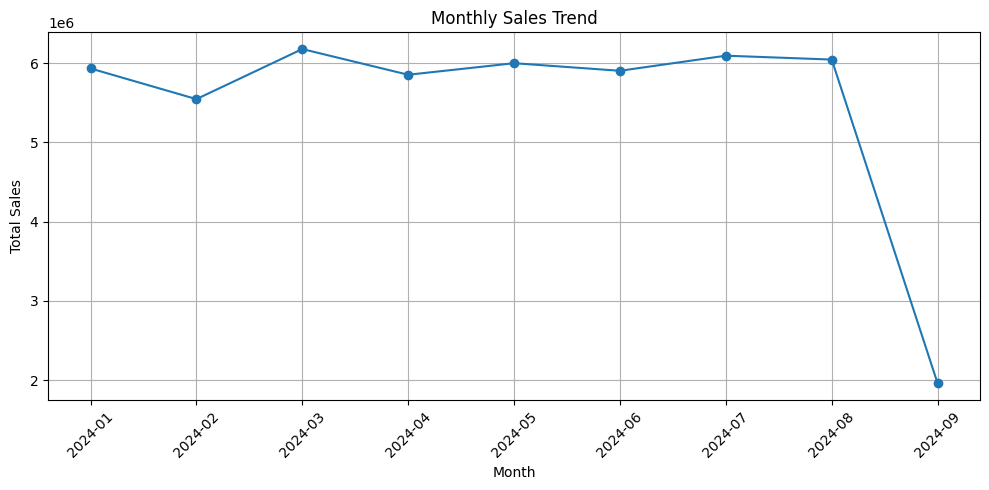

In [3]:
query1 = """
SELECT 
    FORMAT(date_of_sale, 'yyyy-MM') AS sales_month,
    SUM(sales_amount) AS monthly_sales
FROM dbo.sales
GROUP BY FORMAT(date_of_sale, 'yyyy-MM')
ORDER BY sales_month;
"""

df_monthly = pd.read_sql(query1, conn)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(df_monthly['sales_month'], df_monthly['monthly_sales'], marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_13220\196703208.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_store_sales = pd.read_sql(query2, conn)


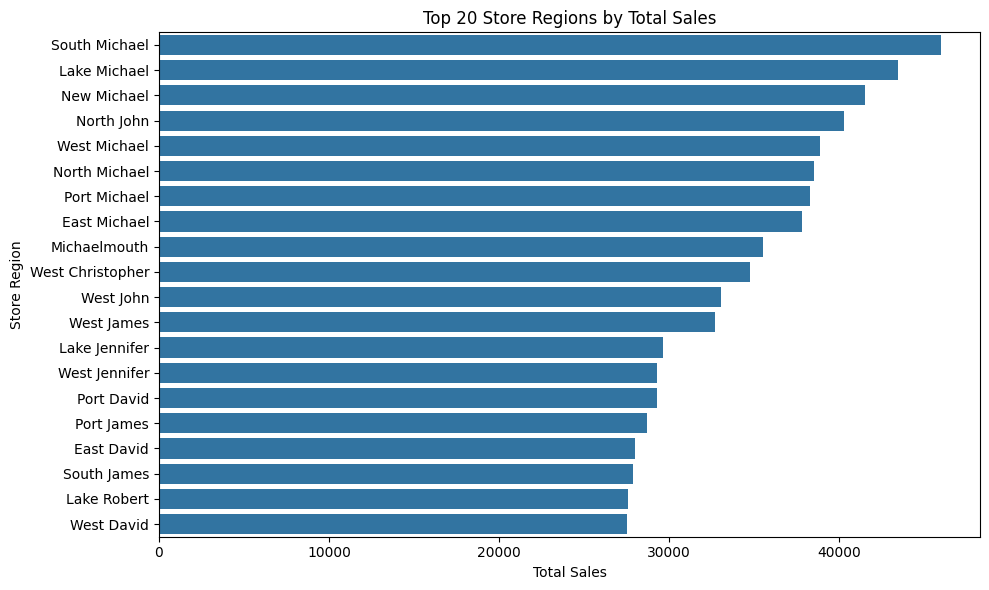

In [7]:
query2 = """
SELECT 
    s.sales_region,
    SUM(sa.sales_amount) AS total_sales
FROM dbo.sales sa
JOIN dbo.stores s ON sa.region_id = s.region_id
GROUP BY s.sales_region
ORDER BY total_sales DESC;
"""

df_store_sales = pd.read_sql(query2, conn)

# Limit to top 20 to avoid rendering issues
top_store_sales = df_store_sales.head(20)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='total_sales', y='sales_region', data=top_store_sales)
plt.title("Top 20 Store Regions by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Store Region")
plt.tight_layout()
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_13220\462825069.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_corr = pd.read_sql(query3, conn)


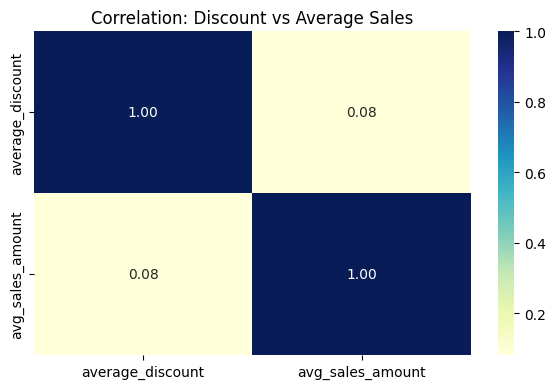

In [8]:
query3 = """
SELECT 
    f.product_category,
    f.average_discount,
    AVG(s.sales_amount) AS avg_sales_amount
FROM dbo.features f
JOIN dbo.sales s ON f.product_category = s.product_category
GROUP BY f.product_category, f.average_discount
ORDER BY f.average_discount DESC;
"""

df_corr = pd.read_sql(query3, conn)

# Create correlation matrix
corr_matrix = df_corr[['average_discount', 'avg_sales_amount']].corr()

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Correlation: Discount vs Average Sales")
plt.tight_layout()
plt.show()


In [9]:
conn.close()